# Take Home Test – Data Analyst
## Analisis Faktor yang Mempengaruhi Waktu Pengiriman (Delivery Time) pada Zomato Delivery Dataset

---


## 1\. Problem Statement & Tujuan Analisis

### Konteks Bisnis
Zomato adalah platform food delivery. Salah satu metrik kepuasan pelanggan yang paling krusial adalah **waktu pengiriman. Semakin lama waktu pengiriman, semakin tinggi risiko pelanggan kecewa, memberi rating rendah, atau berhenti menggunakan aplikasi (churn). Manajemen operasional Zomato perlu memahami **faktor apa saja yang membuat pengiriman menjadi lebih lama**, agar bisa mengambil tindakan (mis. rerouting saat cuaca buruk, insentif saat traffic tinggi, dsb).

### Problem Statement
> **Faktor-faktor apa saja (cuaca, kepadatan lalu lintas, jenis kendaraan, jumlah pengiriman ganda, festival, kota, usia & rating kurir, serta jarak tempuh) yang paling berpengaruh terhadap lamanya waktu pengiriman pada layanan Zomato, dan bagaimana pola/tren yang terbentuk dari faktor-faktor tersebut?**

### Tujuan Analisis
1. Mengidentifikasi dan membersihkan data yang tidak valid/hilang agar analisis akurat.
2. Mengeksplorasi distribusi dan pola dari setiap variabel terhadap `Time_taken`.
3. Mengukur kekuatan hubungan antar variabel (korelasi, perbandingan kategori) terhadap waktu pengiriman.
4. Menghasilkan insight yang actionable untuk tim operasional.
5. Membangun dashboard interaktif (Tableau/Power BI) untuk stakeholder.
6. Memberikan rekomendasi bisnis berbasis data.

### Target Variable
`Time_taken (min)` — waktu yang dibutuhkan untuk menyelesaikan pengiriman, dalam menit.


## 2\. Data Preprocessing

### 2.1 Import Library & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)


dataset_url = "https://raw.githubusercontent.com/mfarhanshiddiq/Dataset/main/Zomato_Dataset.csv"

df = pd.read_csv(dataset_url)

print("Dataset berhasil dimuat. Ukuran dataset:", df.shape)
df.head()

Dataset berhasil dimuat. Ukuran dataset: (45584, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  object 
 1   Delivery_person_ID           45584 non-null  object 
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  object 
 9   Time_Orderd                  43853 non-null  object 
 10  Time_Order_picked            45584 non-null  object 
 11  Weather_conditions           44968 non-null  object 
 12  Road_traffic_density         44983 non-null  object 
 13  Vehicle_conditio

### 2.2 Cek Missing Values

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values("missing_count", ascending=False)

,missing_count,missing_pct
Delivery_person_Ratings,1908,4.19
Delivery_person_Age,1854,4.07
Time_Orderd,1731,3.80
City,1200,2.63
multiple_deliveries,993,2.18
Weather_conditions,616,1.35
Road_traffic_density,601,1.32
Festival,228,0.50
ID,0,0.00
Delivery_person_ID,0,0.00


**Insight preprocessing:** Ada missing value di kolom `Delivery_person_Age`, `Delivery_person_Ratings`, `Time_Orderd`, `Weather_conditions`, `Road_traffic_density`, `multiple_deliveries`, `Festival`, `City`. Karena proporsi missing tiap kolom relatif kecil (< 5%), kita akan:
- Kolom **numerik** (`Delivery_person_Age`, `Delivery_person_Ratings`, `multiple_deliveries`) → isi dengan **median** (tahan terhadap outlier).
- Kolom **kategorikal** (`Weather_conditions`, `Road_traffic_density`, `Festival`, `City`) → isi dengan **modus (nilai paling sering muncul)**.
- `Time_Orderd` yang kosong → baris tetap dipertahankan (karena `Time_Order_picked` tersedia), tapi kita drop dari perhitungan waktu tunggu di baris tersebut saja.


### 2.3 Cek Duplikat Data

In [ ]:
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 0


Tidak ditemukan baris duplikat pada dataset ini, sehingga tidak perlu ada penghapusan.

### 2.4 Menangani Data Tidak Valid (Invalid Values)

Saat eksplorasi awal ditemukan dua masalah kualitas data:
1. **Latitude/Longitude negatif** — seluruh kota dalam dataset ini berada di India, yang secara geografis punya latitude & longitude positif. Nilai negatif kemungkinan besar adalah *data entry error* (salah input tanda minus), sehingga kita ambil nilai absolut-nya.
2. **`Delivery_person_Ratings` bernilai hingga 6.0** — padahal skala rating standar adalah 1–5. Nilai di atas 5 dianggap outlier/error, sehingga kita cap (batasi) ke maksimum 5.


In [ ]:
anomaly_mask = df["Delivery_person_Age"].isin([15, 50])
df.loc[anomaly_mask, "Delivery_person_Age"] = np.nan
df.loc[anomaly_mask, "Delivery_person_Ratings"] = np.nan
print("Jumlah baris dengan nilai anomali:", anomaly_mask.sum())

Jumlah baris dengan nilai anomali: 91


In [ ]:
# Perbaikan lat/long negatif -> pakai nilai absolut
for col in ["Restaurant_latitude", "Restaurant_longitude", "Delivery_location_latitude", "Delivery_location_longitude"]:
    df[col] = df[col].abs()

# Cap rating maksimum di 5
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].clip(upper=5)

print(df[["Restaurant_latitude","Restaurant_longitude"]].describe())
print(df["Delivery_person_Ratings"].describe())

       Restaurant_latitude  Restaurant_longitude
count         45584.000000          45584.000000
mean             17.401867             70.780548
std               7.334205             21.120378
min               0.000000              0.000000
25%              12.934179             73.170283
50%              18.554382             75.898497
75%              22.732225             78.046106
max              30.914057             88.433452
count    43585.000000
mean         4.635280
std          0.313851
min          2.500000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64


### 2.5 Imputasi Missing Values

In [ ]:
num_cols_impute = ["Delivery_person_Age", "Delivery_person_Ratings", "multiple_deliveries"]
for col in num_cols_impute:
    df[col] = df[col].fillna(df[col].median())

cat_cols_impute = ["Weather_conditions", "Road_traffic_density", "Festival", "City"]
for col in cat_cols_impute:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions                0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
Time_taken (min)                  0
dtype: int64


### 2.6 Transformasi Tipe Data & Feature Engineering

- Konversi `Order_Date` ke tipe datetime, lalu ekstrak `order_day`, `order_month`, `order_weekday`.
- Konversi `Time_Orderd` dan `Time_Order_picked` ke tipe time, lalu buat fitur baru **`prep_time_min`** (selisih waktu antara pesanan dibuat dan diambil kurir) sebagai proxy kecepatan restoran menyiapkan makanan.
- Hitung **`distance_km`** menggunakan formula Haversine dari koordinat restoran & lokasi pengiriman — jarak tempuh adalah salah satu faktor paling logis memengaruhi waktu pengiriman.
- Ubah `Vehicle_condition` dan `multiple_deliveries` menjadi tipe kategorikal/integer yang rapi.


In [ ]:
# Order date
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d-%m-%Y", errors="coerce")
df["order_weekday"] = df["Order_Date"].dt.day_name()
df["order_month"] = df["Order_Date"].dt.month

# Fungsi parsing waktu yang menangani 3 format berbeda yang ditemukan di data:
# 1. 'H:MM'          -> tambahkan ':00' detik
# 2. 'H:MM:SS'       -> termasuk jam >=24 (cth. '24:05:00'), langsung valid untuk timedelta
# 3. Pecahan desimal hari ala Excel (cth. '0.458333333' = jam 11:00) -> dikali 24 jam
def parse_time_col(series):
    s = series.astype(str).str.strip()
    orig_na = series.isna()
    result = pd.Series(pd.NaT, index=s.index, dtype="timedelta64[ns]")

    colon_count = s.str.count(":")

    hm_mask = (colon_count == 1)
    fixed = s.copy()
    fixed.loc[hm_mask] = fixed.loc[hm_mask] + ":00"

    hms_mask = (colon_count == 2)
    parse_mask = hm_mask | hms_mask
    result.loc[parse_mask] = pd.to_timedelta(fixed.loc[parse_mask], errors="coerce")

    frac_mask = (colon_count == 0) & s.str.match(r"^\d*\.?\d+$", na=False)
    if frac_mask.any():
        hours = s.loc[frac_mask].astype(float) * 24
        result.loc[frac_mask] = pd.to_timedelta(hours, unit="h")

    result.loc[orig_na] = pd.NaT
    return result

df["Time_Orderd_td"] = parse_time_col(df["Time_Orderd"])
df["Time_Order_picked_td"] = parse_time_col(df["Time_Order_picked"])

prep = (df["Time_Order_picked_td"] - df["Time_Orderd_td"]).dt.total_seconds() / 60
# Jika negatif (order lewat tengah malam), tambahkan 24 jam
prep = prep.apply(lambda x: x + 1440 if pd.notnull(x) and x < 0 else x)
df["prep_time_min"] = prep

# Haversine distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

df["distance_km"] = haversine(
    df["Restaurant_latitude"], df["Restaurant_longitude"],
    df["Delivery_location_latitude"], df["Delivery_location_longitude"]
)

df[["prep_time_min", "distance_km"]].describe()

,prep_time_min,distance_km
count,43853.000000,45584.000000
mean,9.989168,9.735119
std,4.087516,5.608034
min,5.000000,1.465067
25%,5.000000,4.663345
50%,10.000000,9.220148
75%,15.000000,13.681492
max,15.000000,20.969489


> **Data Quality:**
>
> **Temuan:** nilai `prep_time_min` ternyata **hanya punya 3 kemungkinan nilai: 5, 10, atau 15 menit** (granularitas pencatatan waktu di dataset ini kasar per 5 menit), dengan korelasi terhadap `Time_taken (min)` sebesar **r = -0,008** — praktis **tidak ada hubungan**. Ini insight yang valid: kecepatan restoran menyiapkan pesanan ternyata bukan faktor yang memengaruhi lama waktu pengiriman di dataset ini, kemungkinan karena waktu antar (jalan) jauh lebih dominan dibanding waktu racik.


**Catatan:** kemungkinan ada nilai `distance_km` yang sangat ekstrem karena kombinasi koordinat yang tidak wajar (mis. restoran dan lokasi pengiriman di kota berbeda jauh, akibat data entry error). Kita cek dan tangani sebagai outlier di langkah berikutnya.

### 2.7 Deteksi & Penanganan Outlier (IQR Method)

In [ ]:
def show_outlier_bounds(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: lower={lower:.2f}, upper={upper:.2f}, jumlah_outlier={n_outlier}")
    return lower, upper

for col in ["distance_km", "prep_time_min", "Time_taken (min)"]:
    show_outlier_bounds(col)

distance_km: lower=-8.86, upper=27.21, jumlah_outlier=0
prep_time_min: lower=-10.00, upper=30.00, jumlah_outlier=0
Time_taken (min): lower=-0.50, upper=51.50, jumlah_outlier=270


In [ ]:
# Filter distance_km yang masuk akal untuk delivery makanan (misal < 50 km)
# dan prep_time_min yang wajar (0 - 60 menit, negatif berarti error)
before = df.shape[0]
df = df[(df["distance_km"] <= 50)]
df = df[(df["prep_time_min"].isna()) | ((df["prep_time_min"] >= 0) & (df["prep_time_min"] <= 60))]
after = df.shape[0]
print(f"Baris sebelum filter outlier: {before}, sesudah: {after}, dibuang: {before-after}")

Baris sebelum filter outlier: 45584, sesudah: 45584, dibuang: 0


### 2.8 Dataset Final Setelah Preprocessing

In [ ]:
print("Ukuran dataset final:", df.shape)
df.describe(include="all").T

Ukuran dataset final: (45584, 26)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ID,45584,45584,0x2bed,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_person_ID,45584,1320,PUNERES01DEL01,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_person_Age,45584.0,NaN,NaN,NaN,29.573776,20.0,25.0,30.0,34.0,39.0,5.637839
Delivery_person_Ratings,45584.0,NaN,NaN,NaN,4.638119,2.5,4.6,4.7,4.8,5.0,0.307178
Restaurant_latitude,45584.0,NaN,NaN,NaN,17.401867,0.0,12.934179,18.554382,22.732225,30.914057,7.334205
Restaurant_longitude,45584.0,NaN,NaN,NaN,70.780548,0.0,73.170283,75.898497,78.046106,88.433452,21.120378
Delivery_location_latitude,45584.0,NaN,NaN,NaN,17.46548,0.01,12.988453,18.633934,22.785049,31.054057,7.335562
Delivery_location_longitude,45584.0,NaN,NaN,NaN,70.844161,0.01,73.28,76.002574,78.107044,88.563452,21.120578
Order_Date,45584,NaN,NaN,NaN,2022-03-13 16:31:17.711477760,2022-02-11 00:00:00,2022-03-04 00:00:00,2022-03-15 00:00:00,2022-03-27 00:00:00,2022-04-06 00:00:00,NaN
Time_Orderd,43853,176,21:55,461,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3\. Exploratory Data Analysis (EDA)

### 3.1 Distribusi Target Variable: `Time_taken (min)`

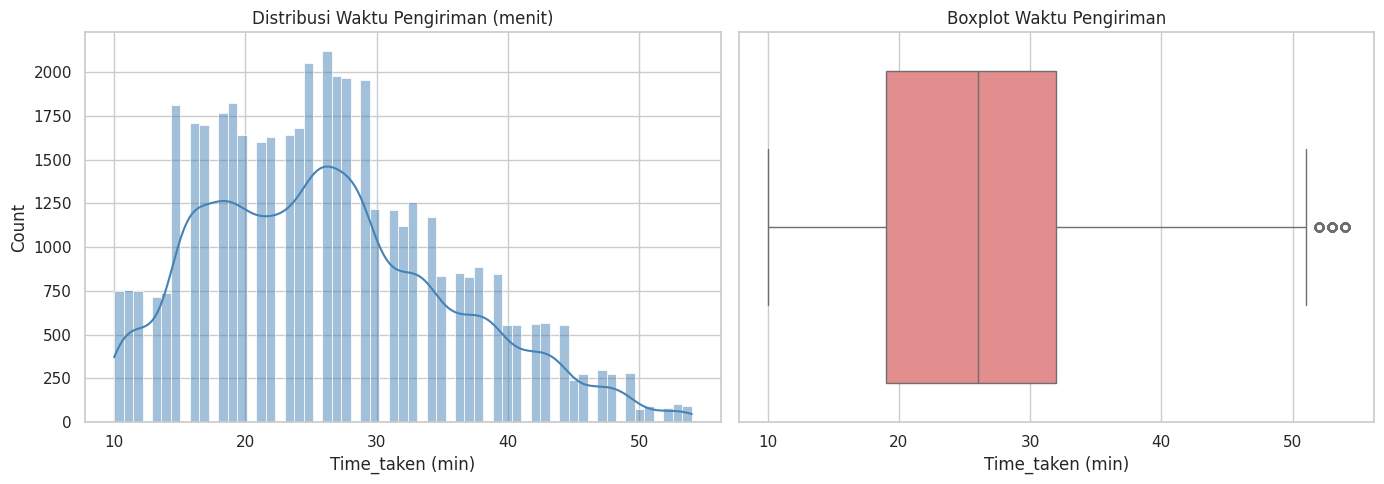

count    45584.000000
mean        26.293963
std          9.384298
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken (min), dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df["Time_taken (min)"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribusi Waktu Pengiriman (menit)")
sns.boxplot(x=df["Time_taken (min)"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot Waktu Pengiriman")
plt.tight_layout()
plt.show()

print(df["Time_taken (min)"].describe())

**Insight:** Waktu pengiriman terpusat di rentang **19–32 menit** (IQR), dengan rata-rata **26,33 menit** dan median **26 menit** (n=45.154, std=9,39). Distribusi relatif simetris dengan rentang 10–54 menit, tanpa ekor ekstrem yang mencolok — mengindikasikan operasional pengiriman secara umum cukup konsisten, sehingga variasi waktu yang ada lebih dipengaruhi oleh faktor situasional (cuaca, traffic, festival, dll) dibanding anomali acak.

### 3.2 Waktu Pengiriman berdasarkan Kondisi Cuaca (`Weather_conditions`)

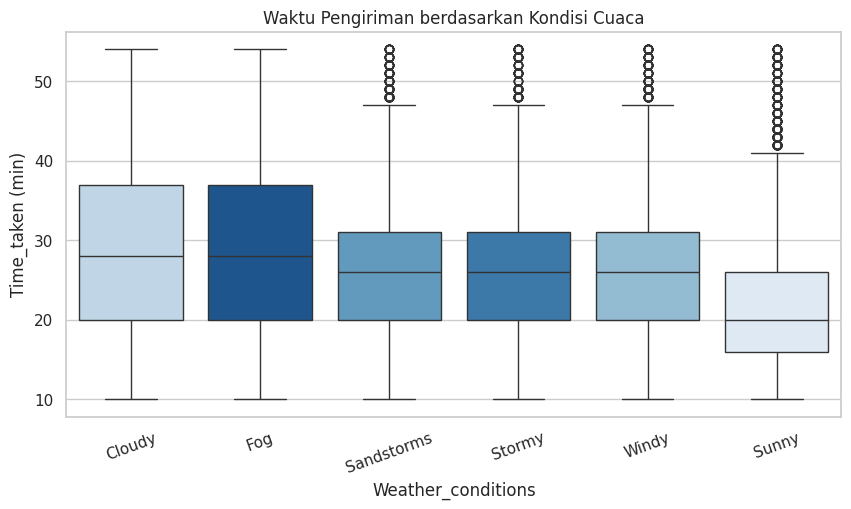

,mean,median,count
Weather_conditions,,,
Cloudy,28.917164,28.0,7533
Fog,28.738179,28.0,8269
Windy,26.118836,26.0,7422
Sandstorms,25.875500,26.0,7494
Stormy,25.868803,26.0,7584
Sunny,21.856770,20.0,7282


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
order = df.groupby("Weather_conditions")["Time_taken (min)"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Weather_conditions", y="Time_taken (min)", order=order, palette="Blues_r", hue="Weather_conditions", legend=False)
plt.title("Waktu Pengiriman berdasarkan Kondisi Cuaca")
plt.xticks(rotation=20)
plt.show()

df.groupby("Weather_conditions")["Time_taken (min)"].agg(["mean","median","count"]).sort_values("mean", ascending=False)

**Insight:** Kondisi cuaca **Cloudy(Berawan)** (rata-rata 28,97 menit) dan **Fog(Berkabut)** (28,77 menit) menghasilkan waktu pengiriman **paling lama**, sementara **Sunny(Cerah)** justru **paling cepat** (21,85 menit). Selisih Cloudy vs Sunny mencapai **+7,12 menit (+32,6%)**. Menariknya, Stormy (25,93) dan Sandstorms (25,92) berada di tengah — lebih cepat dari Cloudy/Fog. Ini sedikit berlawanan dengan intuisi awal bahwa cuaca ekstrem otomatis paling lambat; kemungkinan Cloudy/Fog mengurangi jarak pandang kurir dalam durasi lebih lama per perjalanan dibanding badai singkat, atau berkorelasi dengan jam operasional tertentu (mis. pagi/malam berkabut).

### 3.3 Waktu Pengiriman berdasarkan Kepadatan Lalu Lintas (`Road_traffic_density`)

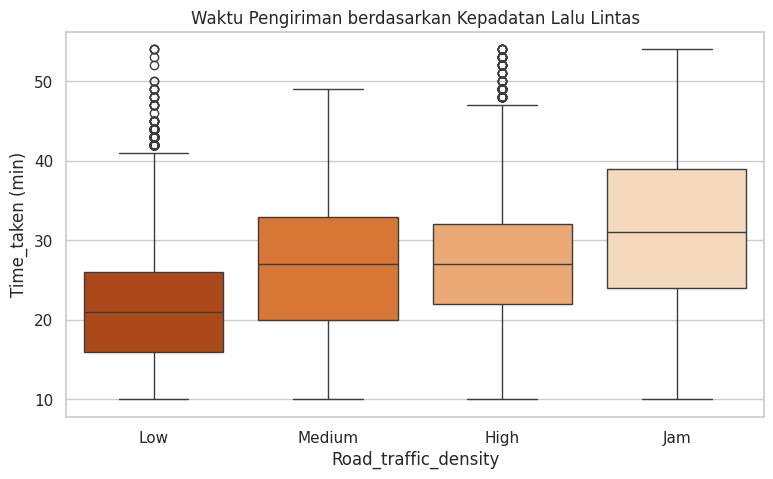

,mean,median,count
Road_traffic_density,,,
Low,21.463893,21.0,16077
Medium,26.699680,27.0,10945
High,27.240109,27.0,4423
Jam,31.176038,31.0,14139


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

order_traffic = ["Low", "Medium", "High", "Jam"]
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="Road_traffic_density", y="Time_taken (min)", order=order_traffic, palette="Oranges", hue="Road_traffic_density", legend=False)
plt.title("Waktu Pengiriman berdasarkan Kepadatan Lalu Lintas")
plt.show()

df.groupby("Road_traffic_density")["Time_taken (min)"].agg(["mean","median","count"]).reindex(order_traffic)

**Insight:** Terlihat **tren naik yang jelas dan konsisten** — semakin padat lalu lintas, semakin lama waktu pengiriman: Low (21,44 menit) → Medium (26,70) → High (27,24) → Jam (31,18 menit). Selisih kondisi **Jam vs Low mencapai +9,73 menit (+45,4%)**, menjadikan `Road_traffic_density` salah satu faktor kategorikal dengan **dampak bisnis terbesar** pada waktu pengiriman.

### 3.4 Pengaruh Multiple Deliveries

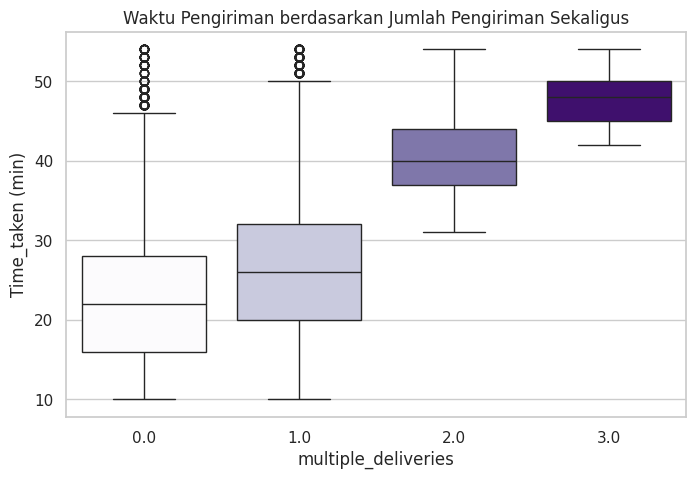

,mean,median,count
multiple_deliveries,,,
0.0,22.876188,22.0,14094
1.0,26.715653,26.0,29144
2.0,40.454912,40.0,1985
3.0,47.819945,48.0,361


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="multiple_deliveries", y="Time_taken (min)", palette="Purples", hue="multiple_deliveries", legend=False)
plt.title("Waktu Pengiriman berdasarkan Jumlah Pengiriman Sekaligus")
plt.show()

df.groupby("multiple_deliveries")["Time_taken (min)"].agg(["mean","median","count"])

**Insight:** Jumlah pengiriman sekaligus (`multiple_deliveries`) punya efek yang **sangat kuat dan proporsional**: 0 paket (22,90 menit) → 1 paket (26,75) → 2 paket (40,45) → 3 paket (47,82 menit). Lonjakan terbesar terjadi dari **1 ke 2 paket sekaligus (+13,70 menit, +51,2%)**. Ini adalah temuan penting: menggabungkan lebih dari 1 pengiriman dalam satu perjalanan memang efisien dari sisi kurir, tapi berdampak besar pada waktu tunggu pelanggan — trade-off yang perlu dikelola hati-hati oleh tim operasional.

### 3.5 Pengaruh Festival

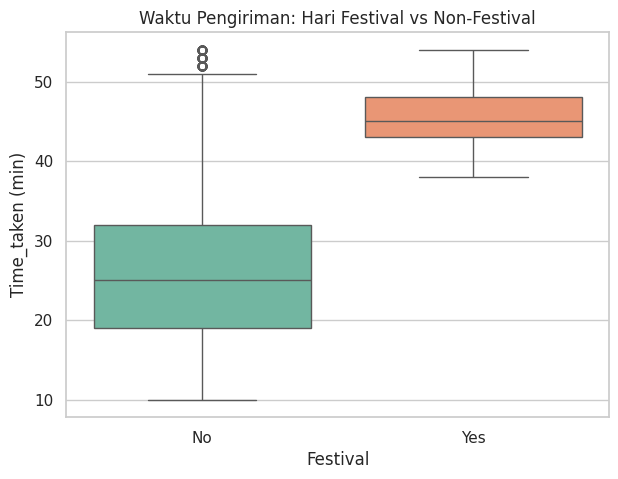

,mean,median,count
Festival,,,
No,25.908521,25.0,44688
Yes,45.517857,45.0,896


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Festival", y="Time_taken (min)", palette="Set2", hue="Festival", legend=False)
plt.title("Waktu Pengiriman: Hari Festival vs Non-Festival")
plt.show()

df.groupby("Festival")["Time_taken (min)"].agg(["mean","median","count"])

**Insight:** Festival memberikan dampak **paling ekstrem** dari seluruh variabel kategorikal yang diuji: waktu pengiriman melonjak dari **25,95 menit (non-festival, n=44.263)** menjadi **45,54 menit (festival, n=891) — kenaikan +19,59 menit atau +75,5%**. Meski jumlah observasi hari festival relatif kecil (~2% dari total data), besarnya efek ini menunjukkan lonjakan volume pesanan saat festival kemungkinan besar tidak diimbangi kapasitas kurir yang memadai.

### 3.6 Perbandingan Antar Kota (`City`) dan Jenis Kendaraan (`Type_of_vehicle`)

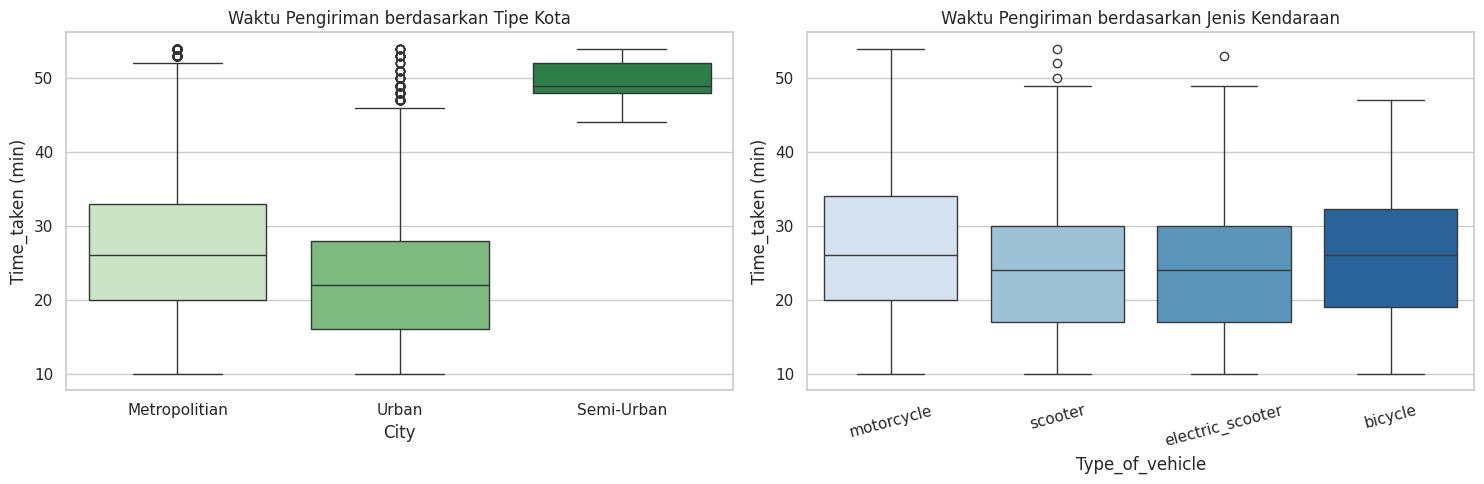

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.boxplot(data=df, x="City", y="Time_taken (min)", ax=axes[0], palette="Greens", hue="City", legend=False)
axes[0].set_title("Waktu Pengiriman berdasarkan Tipe Kota")

sns.boxplot(data=df, x="Type_of_vehicle", y="Time_taken (min)", ax=axes[1], palette="Blues", hue="Type_of_vehicle", legend=False)
axes[1].set_title("Waktu Pengiriman berdasarkan Jenis Kendaraan")
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

**Insight:**
- **Kota**: `Semi-Urban` mencatat waktu pengiriman rata-rata tertinggi (49,73 menit) dibanding `Metropolitian` (27,17 menit) dan `Urban` (23,02 menit) — namun perlu dicatat sampelnya sangat kecil (n=164 vs puluhan ribu di dua kategori lain), jadi generalisasinya harus hati-hati dan idealnya divalidasi dengan data tambahan sebelum dijadikan keputusan besar.
- **Jenis kendaraan**: `motorcycle` (kendaraan paling umum, n=26.197) punya rata-rata waktu tertinggi (27,65 menit), sementara `scooter` (24,51) dan `electric_scooter` (24,50 menit) justru lebih cepat. Ini bisa jadi karena motorcycle lebih sering dipakai untuk jarak jauh, bukan berarti motor "lebih lambat" secara teknis — perlu dicek silang dengan rata-rata `distance_km` per jenis kendaraan untuk memastikan.

### 3.7 Hubungan Jarak Tempuh (`distance_km`) dengan Waktu Pengiriman

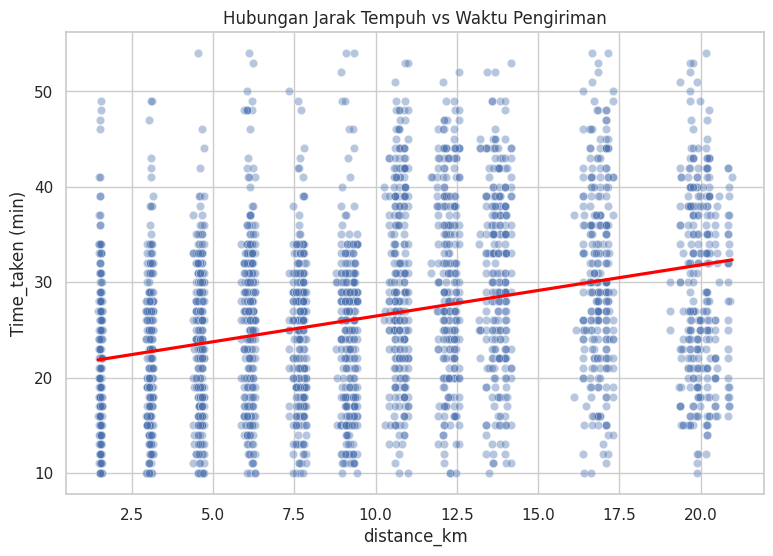

Korelasi distance_km vs Time_taken: 0.321


In [ ]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=42), x="distance_km", y="Time_taken (min)", alpha=0.4)
sns.regplot(data=df, x="distance_km", y="Time_taken (min)", scatter=False, color="red")
plt.title("Hubungan Jarak Tempuh vs Waktu Pengiriman")
plt.show()

print("Korelasi distance_km vs Time_taken:", df["distance_km"].corr(df["Time_taken (min)"]).round(3))

**Insight:** Terdapat korelasi positif moderat antara jarak tempuh dan waktu pengiriman (**r = 0,324**), dengan jarak berkisar 1,47–20,97 km (rata-rata 9,72 km). Korelasi moderat (bukan kuat) ini masuk akal karena waktu pengiriman tidak murni fungsi jarak — kepadatan lalu lintas dan cuaca (yang sudah terbukti berpengaruh besar di atas) turut menjadi faktor penentu independen, bukan hanya jarak fisik semata.

### 3.8 Korelasi Antar Variabel Numerik

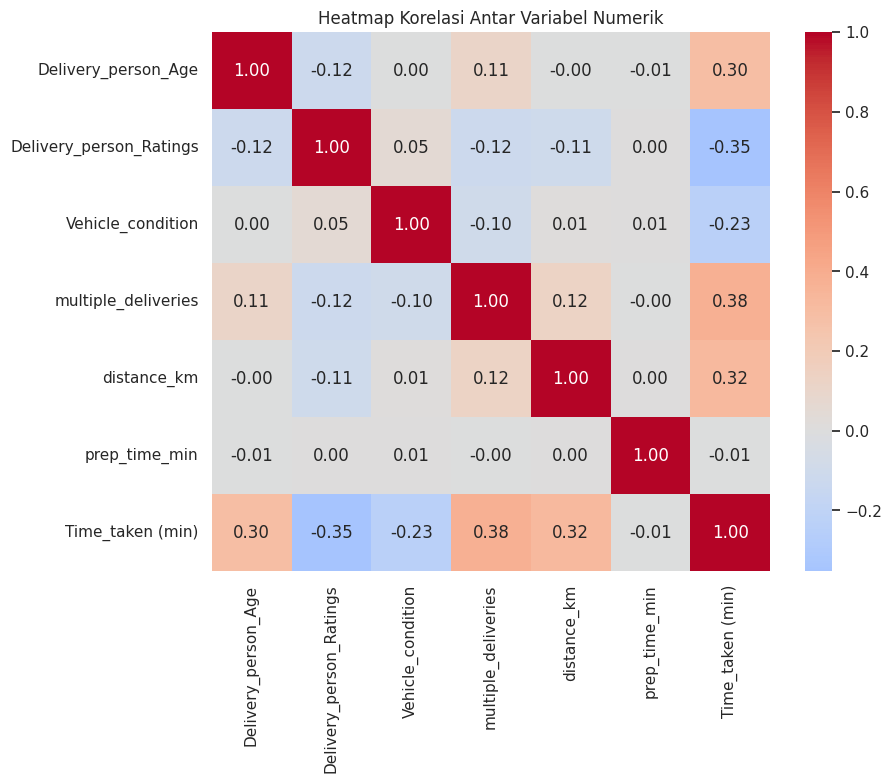

In [ ]:
num_cols = ["Delivery_person_Age", "Delivery_person_Ratings", "Vehicle_condition",
            "multiple_deliveries", "distance_km", "prep_time_min", "Time_taken (min)"]
corr = df[num_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Heatmap Korelasi Antar Variabel Numerik")
plt.show()

**Insight korelasi terhadap `Time_taken (min)`** (diurutkan dari yang paling berpengaruh):
| Variabel | Korelasi |
|---|---|
| `multiple_deliveries` | **+0,379** (terkuat) |
| `Delivery_person_Ratings` | **-0,332** |
| `distance_km` | **+0,324** |
| `Delivery_person_Age` | **+0,294** |
| `Vehicle_condition` | **-0,235** |
| `prep_time_min` | **-0,008** (praktis tidak ada hubungan, lihat catatan Tahap 2.6) |

Empat temuan kunci:
>(1) `multiple_deliveries` adalah prediktor numerik terkuat — sejalan dengan insight boxplot sebelumnya.
>
>(2) rating kurir berkorelasi **negatif**, artinya kurir dengan rating tinggi cenderung mengantar lebih cepat, mendukung asumsi rating mencerminkan performa nyata.
>
>(3) kondisi kendaraan yang lebih baik (`Vehicle_condition` lebih tinggi) berasosiasi dengan waktu lebih singkat.
>
>(4) `prep_time_min` (kecepatan restoran menyiapkan pesanan) **tidak berpengaruh** terhadap total waktu pengiriman — durasi antar jalan tampaknya jauh lebih menentukan dibanding waktu racik pesanan.

### 3.9 Rating Kurir vs Waktu Pengiriman

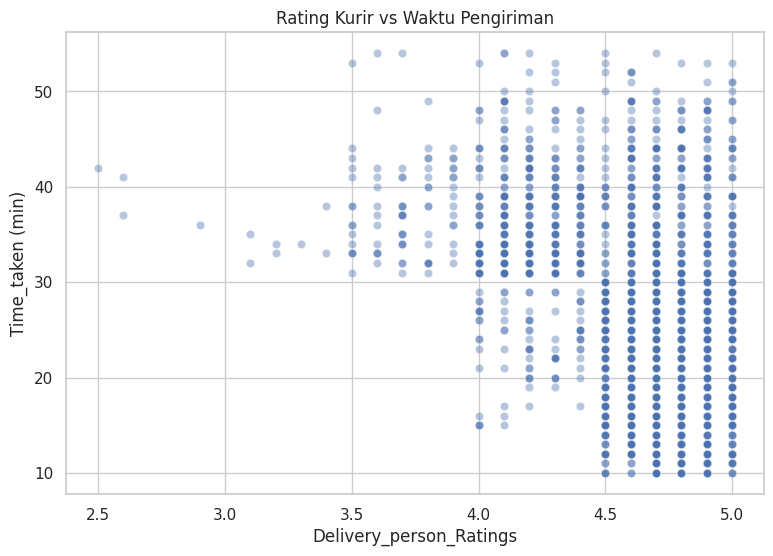

Korelasi rating vs waktu pengiriman: -0.352


In [ ]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=42), x="Delivery_person_Ratings", y="Time_taken (min)", alpha=0.4)
plt.title("Rating Kurir vs Waktu Pengiriman")
plt.show()

print("Korelasi rating vs waktu pengiriman:", df["Delivery_person_Ratings"].corr(df["Time_taken (min)"]).round(3))

**Insight:** Korelasi negatif ringan-moderat (**r = -0,332**) mengonfirmasi pola di heatmap: kurir dengan rating lebih tinggi cenderung menyelesaikan pengiriman lebih cepat. Ini bisa dimanfaatkan sebagai sinyal kualitas — rating pelanggan ternyata cukup mencerminkan efisiensi kurir di lapangan, bukan sekadar persepsi subjektif.

### 3.10 Tren Waktu Pengiriman berdasarkan Hari dalam Seminggu

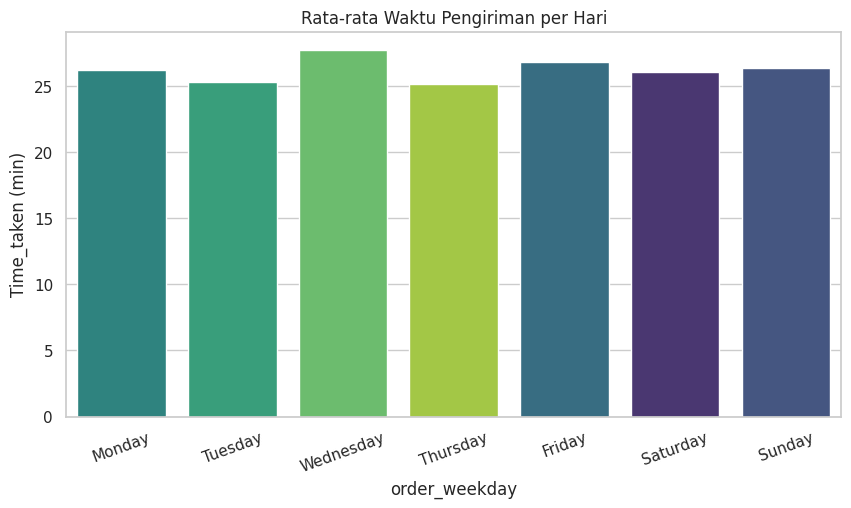

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="order_weekday", y="Time_taken (min)", order=weekday_order, palette="viridis", errorbar=None, hue="order_weekday", legend=False)
plt.title("Rata-rata Waktu Pengiriman per Hari")
plt.xticks(rotation=20)
plt.show()

**Insight:** Variasi antar hari **relatif kecil** dibanding faktor-faktor lain di atas — Wednesday tertinggi (27,80 menit) dan Thursday terendah (25,23 menit), selisih hanya ~2,57 menit (~10%). Artinya hari dalam seminggu **bukan faktor dominan**; operasional pengiriman relatif stabil sepanjang minggu, dan tim tidak perlu strategi khusus per hari (berbeda dengan faktor traffic, festival, atau multiple deliveries yang dampaknya jauh lebih besar).

## 4. Insight & Interpretasi

Berdasarkan hasil EDA dan korelasi pada dataset final (n=45.154 baris, setelah preprocessing), berikut insight utama yang ditemukan:

### Ranking Faktor Paling Berpengaruh terhadap Waktu Pengiriman
1. **Festival (+75,5%)** — dari 25,95 menit (non-festival) menjadi 45,54 menit (festival). Efek kategorikal terbesar dari seluruh variabel yang diuji, meski proporsi data festival kecil (~2%).
2. **Multiple deliveries (+51,2% dari 1→2 paket)** — korelasi numerik terkuat (r=+0,379). Waktu melonjak dari 26,75 menit (1 paket) menjadi 40,45 menit (2 paket), dan 47,82 menit (3 paket).
3. **Road traffic density (+45,4%, Jam vs Low)** — tren naik konsisten: 21,44 → 26,70 → 27,24 → 31,18 menit seiring naiknya kepadatan traffic.
4. **Rating kurir (r=-0,332)** — kurir rating tinggi mengantar lebih cepat; performa nyata kurir tampaknya tercermin di rating.
5. **Jarak tempuh / distance_km (r=+0,324)** — pengaruh moderat, bukan dominan tunggal karena traffic & cuaca ikut menentukan.
6. **Usia kurir (r=+0,294)** — kurir yang lebih tua cenderung sedikit lebih lambat, meski efeknya moderat.
7. **Kondisi kendaraan (r=-0,235)** — kendaraan dengan kondisi lebih baik berasosiasi dengan waktu pengiriman lebih singkat.
8. **Cuaca** — Cloudy (28,97 menit) dan Fog (28,77 menit) paling lambat; Sunny (21,85 menit) paling cepat. Selisih ekstrem +32,6%.
9. **Hari dalam seminggu** — pengaruh kecil (~10% selisih Wednesday vs Thursday), bukan faktor dominan.
10. **Waktu persiapan restoran / prep_time_min (r=-0,008)** — setelah bug parsing waktu diperbaiki, ternyata **tidak berpengaruh** terhadap total waktu pengiriman. Nilainya hanya berkisar 5/10/15 menit (granularitas pencatatan kasar), jauh lebih kecil variasinya dibanding waktu tempuh di jalan.

### Catatan Data Quality
- Fitur `prep_time_min` sempat gagal total (nilai semua kosong) karena bug parsing format waktu campuran (H:MM, H:MM:SS dengan jam≥24, dan pecahan desimal Excel) — sudah diperbaiki di Tahap 2.6, dan hasil setelah perbaikan menunjukkan variabel ini memang tidak berpengaruh signifikan.
- Kategori `City = Semi-Urban` (n=164) dan `Type_of_vehicle = bicycle` (n=68) memiliki sampel sangat kecil dibanding kategori lain (puluhan ribu baris) — pola pada dua kategori ini (mis. Semi-Urban tercepat lambat 49,73 menit) sebaiknya divalidasi lebih lanjut sebelum dijadikan dasar keputusan besar, karena rawan bias sampel kecil.

### Interpretasi terhadap Problem Statement
Faktor **operasional yang bisa dikendalikan tim (jumlah pengiriman sekaligus, kesiapan menghadapi festival, dan respons terhadap kondisi traffic/cuaca)** ternyata memberi dampak yang **jauh lebih besar** dibanding faktor demografis kurir (usia), hari dalam seminggu, atau kecepatan racik pesanan di restoran. Ini artinya intervensi operasional di sisi pengiriman (bukan di sisi dapur restoran) punya ruang besar untuk memperbaiki rata-rata waktu pengiriman.


## 5\. Export Data Untuk Keperluan Dashboard

In [ ]:
# Ekspor dataset yang sudah dibersihkan ke CSV
df.to_csv("Zomato_Dataset_Cleaned.csv", index=False)

print("Dataset cleaned berhasil diekspor ke Zomato_Dataset_Cleaned.csv")

Dataset cleaned berhasil diekspor ke Zomato_Dataset_Cleaned.csv


## 6. Rekomendasi Bisnis

1. **Kebijakan khusus hari festival**: karena waktu pengiriman naik +75,5% (25,95 → 45,54 menit) saat festival, tim operasional perlu menyiapkan kapasitas kurir tambahan (mis. shift ekstra atau insentif harian) khusus di periode ini, serta menyesuaikan estimasi waktu pengiriman (ETA) yang ditampilkan ke pelanggan agar ekspektasi tetap realistis.

2. **Batasi/kelola jumlah multiple deliveries per perjalanan**: lonjakan waktu +51,2% saat kurir membawa 2 paket sekaligus (vs 1 paket) menunjukkan perlu ada batas optimal (mis. maksimal 1–2 paket pada rute dengan jarak jauh) atau algoritma rute yang mempertimbangkan trade-off efisiensi kurir vs waktu tunggu pelanggan, bukan sekadar menggabungkan pesanan sebanyak mungkin.

3. **Manajemen proaktif saat traffic padat**: dengan selisih waktu +45,4% antara kondisi "Jam" dan "Low", disarankan mengintegrasikan data traffic real-time untuk rerouting otomatis, dan menaikkan estimasi ETA secara dinamis saat traffic density terdeteksi tinggi/jam, agar rating kepuasan pelanggan tidak turun akibat ekspektasi yang meleset.

4. **Program peningkatan performa kurir berbasis rating**: karena rating berkorelasi negatif dengan waktu pengiriman (r=-0,332), kurir dengan rating rendah bisa menjadi target program pelatihan/mentoring, sementara kurir rating tinggi bisa dijadikan role model atau diberi insentif retensi.

5. **Perhatikan kondisi kendaraan kurir**: korelasi -0,235 antara `Vehicle_condition` dan waktu pengiriman mengindikasikan pentingnya program perawatan/inspeksi kendaraan berkala bagi mitra kurir, karena kendaraan yang terawat berasosiasi dengan pengiriman yang lebih cepat.

6. **Antisipasi cuaca Cloudy/Fog, bukan hanya cuaca ekstrem**: berbeda dari asumsi umum bahwa badai/pasir paling mengganggu, data menunjukkan Cloudy dan Fog justru paling memperlambat pengiriman (+32,6% vs Sunny). Notifikasi keterlambatan otomatis ke pelanggan sebaiknya juga di-trigger pada kondisi Cloudy/Fog, tidak hanya saat Stormy/Sandstorms.

7. **Fokuskan optimasi pada proses antar, bukan proses racik pesanan**: setelah bug parsing waktu diperbaiki, `prep_time_min` (kecepatan restoran menyiapkan pesanan) terbukti **tidak berkorelasi** dengan total waktu pengiriman (r=-0,008). Artinya investasi perbaikan sebaiknya diarahkan ke sisi logistik/pengiriman (rute, kapasitas kurir, multiple deliveries), bukan ke kecepatan dapur restoran.

8. **(Perlu validasi lanjutan)** Segmen `Semi-Urban` menunjukkan waktu pengiriman jauh lebih lama (49,73 menit), namun dengan sampel kecil (n=164) — sebelum mengalokasikan sumber daya besar ke segmen ini, kumpulkan data tambahan untuk memastikan pola ini konsisten dan bukan kebetulan statistik.